   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
K = 1, Accuracy = 1.00
K = 3, Accuracy = 1.00
K = 5, Accuracy = 1.00
K = 7, Accuracy = 1.00
K = 9, Accuracy = 1.00

Final Accuracy: 1.0


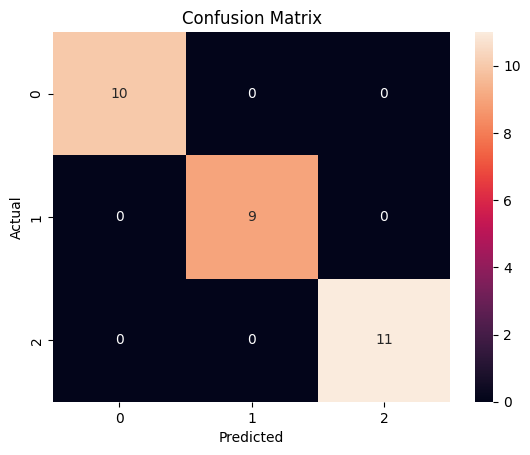

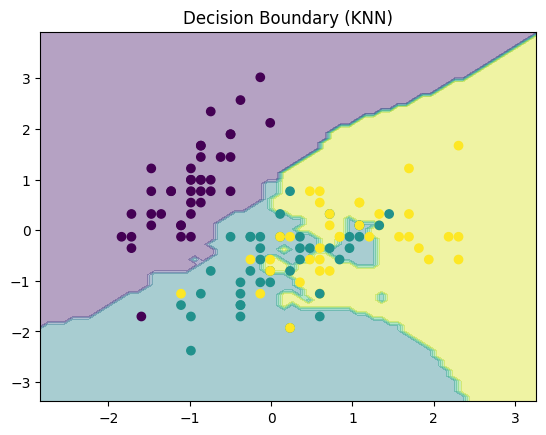

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


df = pd.read_csv('Iris.csv')   # Upload file in Colab

print(df.head())

# ===============================
# 3. Data Preprocessing
# ===============================
# Drop Id column
df = df.drop('Id', axis=1)

# Features and Target
X = df.drop('Species', axis=1)
y = df['Species']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 4. Normalization (IMPORTANT)
# ===============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# 5. Train KNN Model
# ===============================
k_values = [1, 3, 5, 7, 9]

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"K = {k}, Accuracy = {acc:.2f}")

# ===============================
# 6. Final Model (Best K = 5)
# ===============================
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Accuracy
print("\nFinal Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===============================
# 7. Decision Boundary (2 features only)
# ===============================
from matplotlib.colors import ListedColormap

# Take only 2 features for visualization
X_vis = X.iloc[:, :2].values
y_vis = df['Species'].astype('category').cat.codes

X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis, y_vis, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_vis = scaler.fit_transform(X_train_vis)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_vis, y_train_vis)

# Mesh grid
x_min, x_max = X_train_vis[:, 0].min() - 1, X_train_vis[:, 0].max() + 1
y_min, y_max = X_train_vis[:, 1].min() - 1, X_train_vis[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X_train_vis[:, 0], X_train_vis[:, 1], c=y_train_vis)
plt.title("Decision Boundary (KNN)")
plt.show()